In [92]:
path = r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-13\data\lev-13_merged.parquet"

# import 
import pandas as pd
import polars as pl
import missingno as msgo
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:

# Import Data and filter
pdf = pl.read_parquet(path)
display(f"Before Filtering the shape {pdf.shape}")
pdf = pdf.filter(
    pl.col('State') == '23'
)
display(f"After Filter the shape {pdf.shape}")


'Before Filtering the shape (9903498, 27)'

'After Filter the shape (650384, 27)'

In [94]:
pdf['FIRST_PURCHASE_NUMBER']

FIRST_PURCHASE_NUMBER
f64
1.0
null
1.0
1.0
null
…
null
null
null


In [95]:
pdf.columns

['Survey_Name',
 'Year',
 'FSU_Serial_No',
 'Sector',
 'State',
 'NSS_Region',
 'District',
 'Stratum',
 'Sub_stratum',
 'Panel',
 'Sub_sample',
 'FOD_Sub_Region',
 'Sample_SU_No',
 'Sample_Sub_Division_No',
 'Second_Stage_Stratum_No',
 'Sample_Household_No',
 'Questionnaire_No',
 'Level',
 'ITEM_CODE',
 'FIRST_PURCHASE_NUMBER',
 'PURCHASED_ON_HIRE',
 'FIRST_PURCHASE_VALUE',
 'REPAIR_COST',
 'SECOND_HAND_NUMBER',
 'SECOND_HAND_VALUE',
 'TOTAL_EXPENDITURE',
 'MULTIPLIER']

In [96]:
cols = [
    'ITEM_CODE',
'FIRST_PURCHASE_NUMBER',
'PURCHASED_ON_HIRE',
'FIRST_PURCHASE_VALUE',
'REPAIR_COST',
'TOTAL_EXPENDITURE',
]

pdf = pdf[cols]

display(f"Desire Filter shape {pdf.shape}")


'Desire Filter shape (650384, 6)'

In [97]:

# str -> int 
pdf = pdf.with_columns(
    [pl.col(col).cast(pl.Int16, strict=False) for col in pdf.columns]
)

display(pdf.schema)

# MP Data
mp_df = pdf.to_pandas()

Schema([('ITEM_CODE', Int16),
        ('FIRST_PURCHASE_NUMBER', Int16),
        ('PURCHASED_ON_HIRE', Int16),
        ('FIRST_PURCHASE_VALUE', Int16),
        ('REPAIR_COST', Int16),
        ('TOTAL_EXPENDITURE', Int16)])

In [98]:
colors = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59']  
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

palette = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59', '#ccff33', '#ff36ab', '#e0fbfc', '#3772ff', '#45062e']  
sns.set_palette(palette)

In [99]:
mp_df['ITEM_CODE'].unique()

array([ 44,  48, 440, 442, 553, 554, 555, 570, 573, 586, 587, 591, 601,
       602, 603, 630, 631, 632, 643,  50, 580, 600, 623, 560, 432, 441,
       552, 571, 641, 584,  35, 622, 620, 640, 588,  97, 583, 592, 556,
       633, 564, 625, 563, 621, 561, 550,  42, 572, 562, 581, 551,  41,
       585, 590, 611, 624, 582, 557, 604,  36,  46, 642,  40,  43,  37,
        47, 610,  45, 559, 569, 579, 599, 609, 629, 639, 649,  99, 619],
      dtype=int16)

In [100]:
mapping = {
    44: "air cooler",
    48: "mixer/grinder, juicer, food processor",
    440: "spectacles/goggles, contact lenses",
    442: "other minor durable-type goods (torch, lock, lighter, etc.)",
    553: "suitcase, trolley bag, duffle bag, trunk, etc.",
    554: "back-pack, handbags, vanity bags, purse, clutch, etc.",
    555: "carpet, daree & other floor mattings",
    570: "stainless steel utensils",
    573: "other crockery & utensils (jars, containers, cutlery, dinner set, etc.)",
    586: "stove, gas burner, induction",
    587: "pressure cooker/pressure pan",
    591: "electric iron, heater, toaster, micro-oven, electric kettle, vacuum cleaner, & other electric heating appliances",
    601: "motor cycle, scooter",
    602: "motor car, jeep",
    603: "tyres & tubes",
    630: "bathroom and sanitary equipment",
    631: "plugs, switches & other electrical fittings",
    632: "residential building & land (cost of minor repairs only)",
    643: "other jewellery and ornaments (artificial jewellery, etc.)",
    50: "water bottle/feeding bottle",
    580: "electric fan",
    600: "bicycle",
    623: "mobile handset",
    560: "television",
    432: "sports goods (badminton racket, shuttle cock, football, cricket bat, toys, etc.)",
    441: "umbrella, raincoat, helmet",
    552: "chair, stool, bench, table",
    571: "other metal utensils (non-stick cookware, etc.)",
    641: "silver jewellery",
    584: "sewing machine",
    35: "headphone, earphone, ear pod, bluetooth devices/speakers, etc.",
    622: "PC/Laptop/tablet, other peripherals incl. software",
    620: "clock, watch, smartwatch, fitness tracker",
    640: "gold/diamond/platinum jewellery",
    588: "refrigerator/freezers",
    97: "other sports goods",
    583: "lantern, lamp, electric lampshade, emergency light",
    592: "other cooking/household appliances",
    556: "paintings, drawings, engravings, etc.",
    633: "other durables",
    564: "other goods for recreation (radio, VCR/VCD/DVD player, home theatre, play station, etc.)",
    625: "other personal goods (power banks, hair dryers, straighteners, trimmers, etc.)",
    563: "musical instruments",
    621: "other machines for household work",
    561: "camera & photographic equipment",
    550: "bedstead",
    42: "nebulizer",
    572: "casseroles, thermos, flask, thermoware",
    562: "CD, DVD, pen-drive, external hard disk",
    581: "air conditioner",
    551: "almirah, dressing table",
    41: "massagers",
    585: "washing machine",
    590: "water purifier",
    611: "other medical equipment (blood pressure monitoring machine, etc.)",
    624: "telephone instrument (landline)",
    582: "inverter, generators, stabilizers",
    557: "other furniture & fixtures (couch, sofa, etc.)",
    604: "other transport equipment",
    36: "exercise equipment: treadmill, fitness cycle, etc.",
    46: "geysers & hot water systems, sterilizers",
    642: "jewels, pearls, precious stones",
    40: "wheelchair",
    43: "electric air heaters & blowers",
    37: "weighing machine",
    47: "ventilation system (exhaust, chimney, etc.)",
    610: "hearing aids & orthopaedic equipment",
    45: "air purifier",
    559: "furniture & fixtures: sub-total",
    569: "goods for recreation: sub-total",
    579: "crockery & utensils: sub-total",
    599: "cooking & other household appliances: sub-total",
    609: "personal transport equipment: sub-total",
    629: "other personal goods: sub-total",
    639: "residential building, land and other durables: sub-total",
    649: "jewellery & ornaments: sub-total",
    99: "sports goods: sub-total",
    619: "medical equipment: sub-total"
}

In [101]:
mp_df['Item_map'] = mp_df['ITEM_CODE'].map(mapping)

In [102]:
mp_df.columns

Index(['ITEM_CODE', 'FIRST_PURCHASE_NUMBER', 'PURCHASED_ON_HIRE',
       'FIRST_PURCHASE_VALUE', 'REPAIR_COST', 'TOTAL_EXPENDITURE', 'Item_map'],
      dtype='object')

In [103]:
mp_df['PURCHASED_ON_HIRE'].value_counts()

PURCHASED_ON_HIRE
2.0    200328
1.0       462
Name: count, dtype: int64

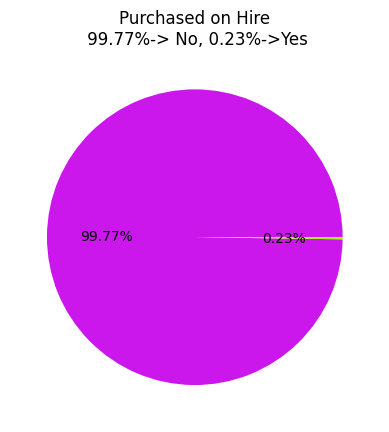

In [104]:
plt.pie(mp_df['PURCHASED_ON_HIRE'].value_counts(), autopct='%1.2f%%',)
plt.title('Purchased on Hire\n 99.77%-> No, 0.23%->Yes')
plt.show()

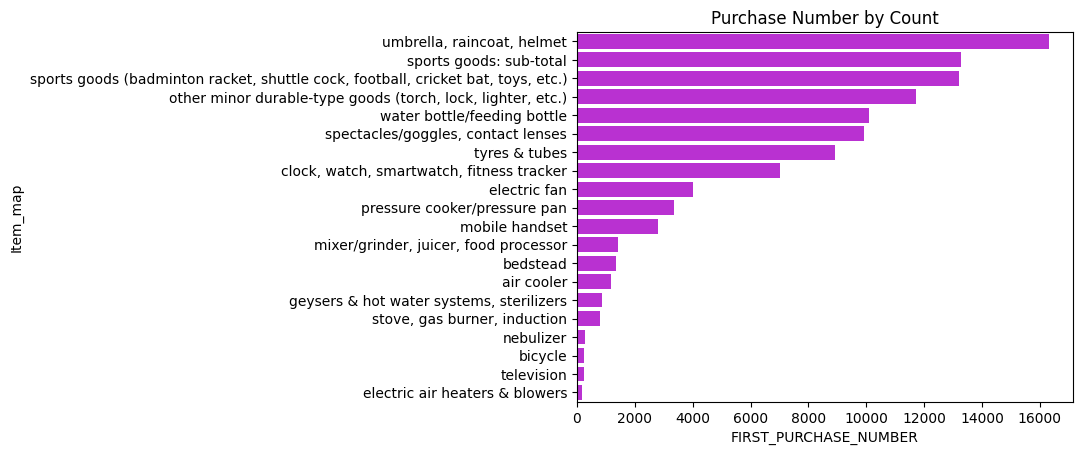

In [105]:
sns.barplot(mp_df.groupby('Item_map')['FIRST_PURCHASE_NUMBER'] \
    .count() \
    .sort_values(ascending=False)\
    .head(20),
    orient='h')

plt.title('Purchase Number by Count')
plt.show()

In [106]:
mp_df.groupby('Item_map')['FIRST_PURCHASE_NUMBER'].count().

SyntaxError: invalid syntax (606991634.py, line 1)

In [ ]:
pdf.columns

['ITEM_CODE',
 'FIRST_PURCHASE_NUMBER',
 'PURCHASED_ON_HIRE',
 'FIRST_PURCHASE_VALUE',
 'REPAIR_COST',
 'TOTAL_EXPENDITURE']

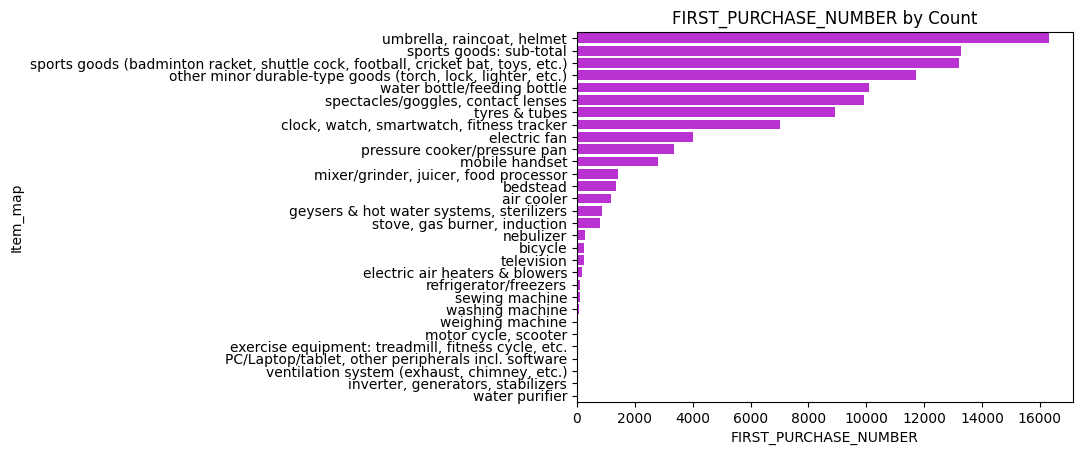

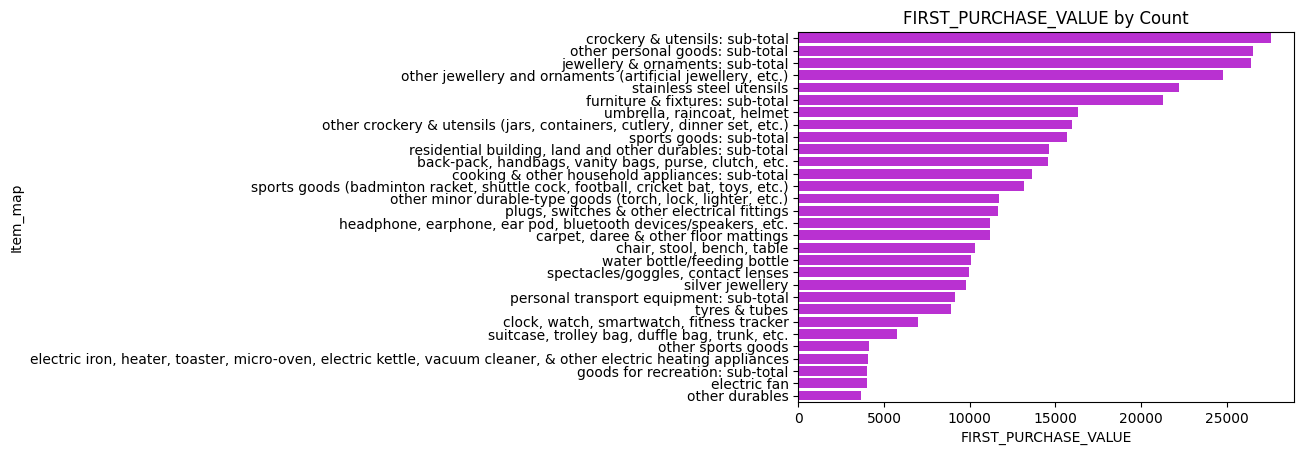

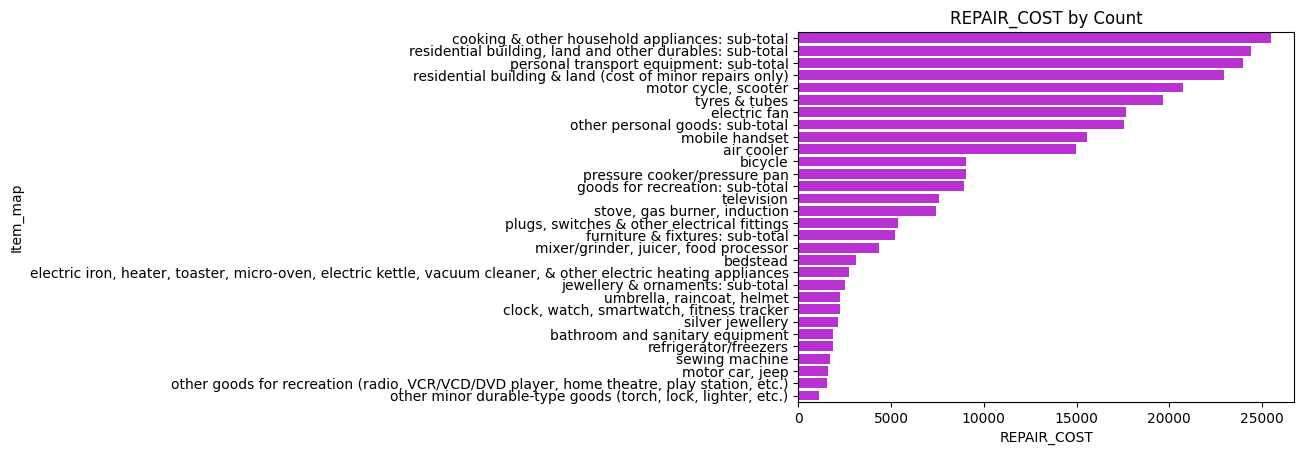

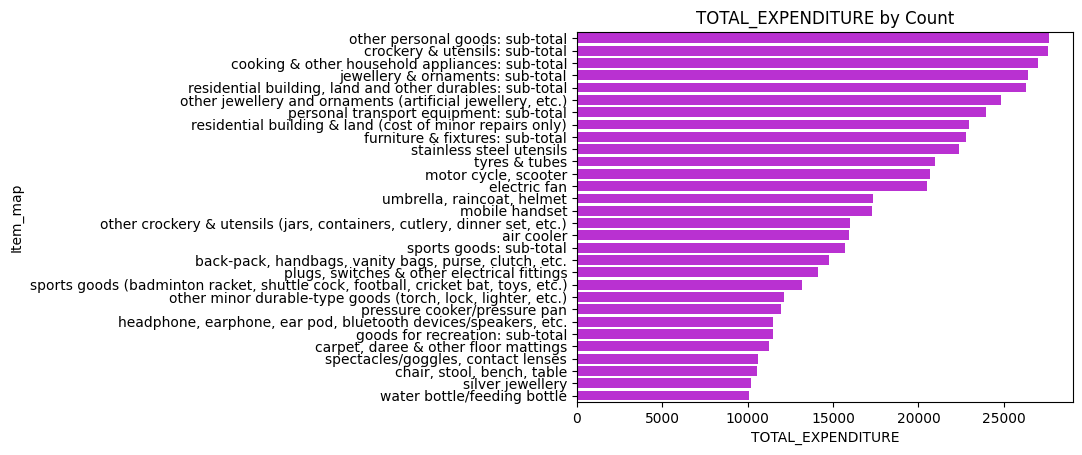

In [ ]:
for col in ['FIRST_PURCHASE_NUMBER', 'FIRST_PURCHASE_VALUE', 'REPAIR_COST', 'TOTAL_EXPENDITURE']:
    for ht in ['head']
    sns.barplot(mp_df.groupby('Item_map')[col] \
        .count() \
        .sort_values(ascending=False)\
        .head(30),
        orient='h')

    plt.title(f'Top 30 {col} by Count')
    plt.show()